--- Missing Values Check ---
Missing values in Train: False
Missing values in Test: False

--- Exploratory Data Analysis ---


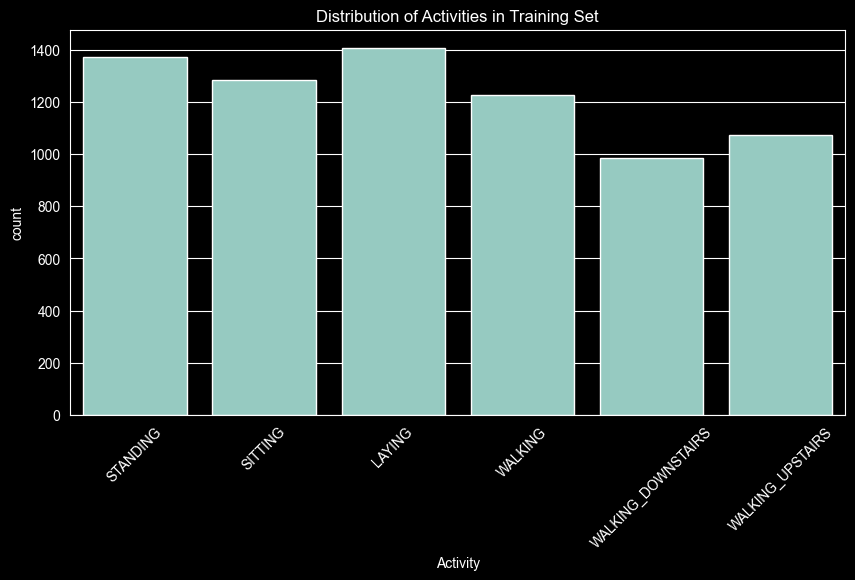

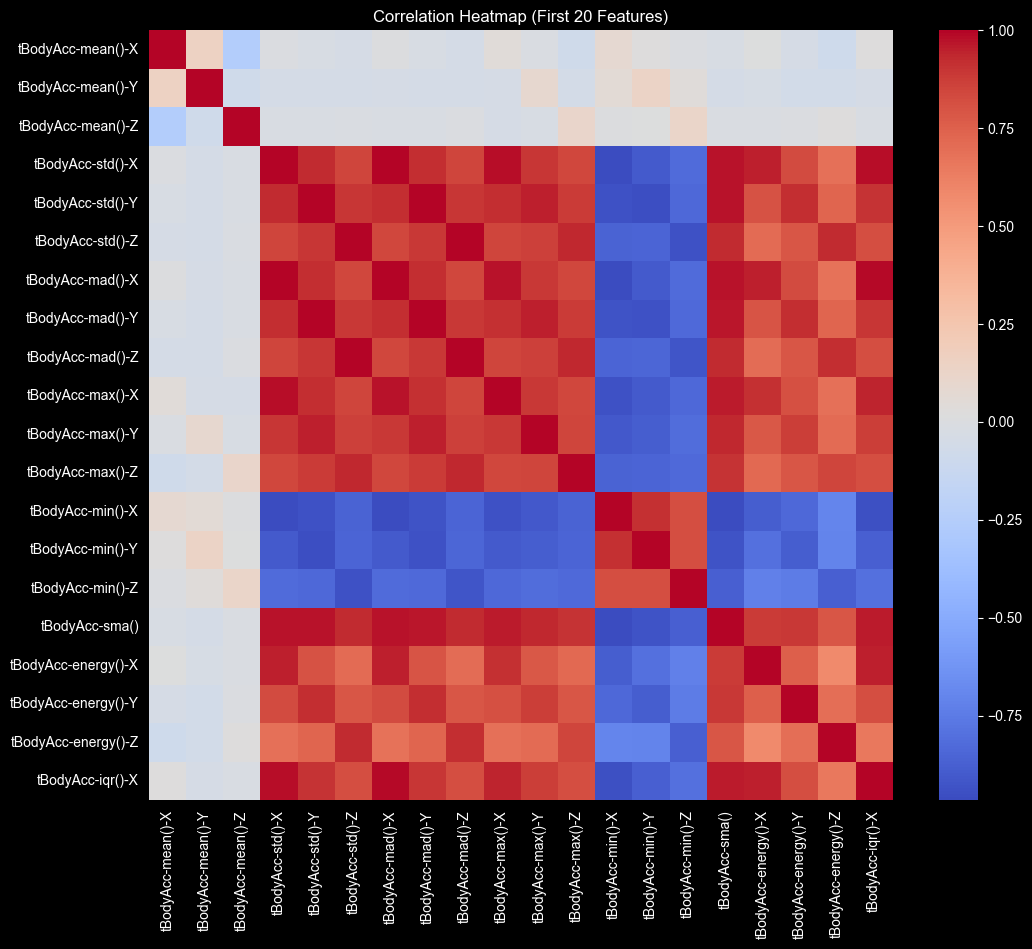

Features reduced from 562 to 562 by removing constants.

Overall Accuracy: 92.60%

Classification Report:
                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       537
           SITTING       0.91      0.90      0.90       491
          STANDING       0.91      0.92      0.91       532
           WALKING       0.89      0.97      0.93       496
WALKING_DOWNSTAIRS       0.96      0.85      0.90       420
  WALKING_UPSTAIRS       0.89      0.90      0.90       471

          accuracy                           0.93      2947
         macro avg       0.93      0.92      0.92      2947
      weighted avg       0.93      0.93      0.93      2947



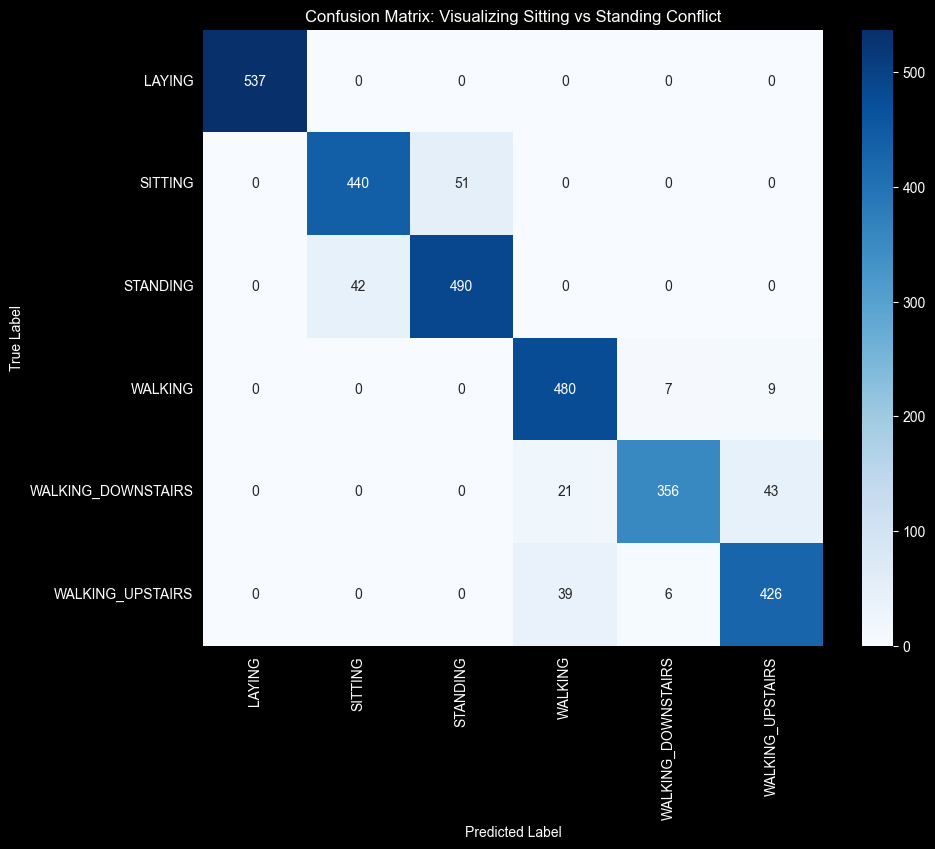


Top 10 Most Predictive Features:
1. tGravityAcc-mean()-X (0.0327)
2. tGravityAcc-max()-X (0.0309)
3. tGravityAcc-min()-X (0.0290)
4. tGravityAcc-max()-Y (0.0283)
5. angle(Y,gravityMean) (0.0266)
6. tGravityAcc-min()-Y (0.0235)
7. tGravityAcc-mean()-Y (0.0234)
8. tGravityAcc-energy()-X (0.0222)
9. angle(X,gravityMean) (0.0221)
10. tBodyAccMag-std() (0.0163)
Sum of importances: 1.00


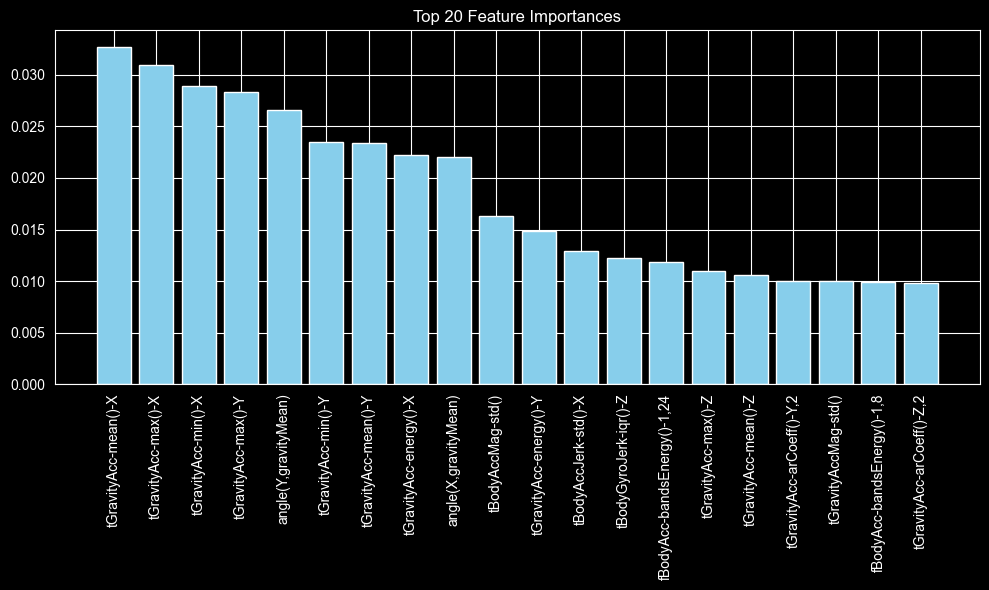

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import VarianceThreshold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# ==========================================
# 1. Data Preparation & Cleaning
# ==========================================
# Load the datasets
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

#  (Requirement: Data Science Process - Cleaning)
print("--- Missing Values Check ---")
print(f"Missing values in Train: {train_df.isnull().values.any()}")
print(f"Missing values in Test: {test_df.isnull().values.any()}")

# Separate features (X) and labels (y)
X_train = train_df.iloc[:, :-1]
y_train = train_df.iloc[:, -1]
X_test = test_df.iloc[:, :-1]
y_test = test_df.iloc[:, -1]

# Label Encoding
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# ==========================================
# 2. Exploratory Data Analysis
# ==========================================
print("\n--- Exploratory Data Analysis ---")

# A. Activity Distribution
plt.figure(figsize=(10, 5))
sns.countplot(x=y_train)
plt.title("Distribution of Activities in Training Set")
plt.xticks(rotation=45)
plt.show()

# B. Correlation Heatmap
plt.figure(figsize=(12, 10))
top_20_corr = X_train.iloc[:, :20].corr()
sns.heatmap(top_20_corr, annot=False, cmap='coolwarm')
plt.title("Correlation Heatmap (First 20 Features)")
plt.show()


# ==========================================
# 3. Feature Selection
# ==========================================
# Remove constant features (Variance Threshold)
selector = VarianceThreshold(threshold=0)
X_train_reduced = selector.fit_transform(X_train)
X_test_reduced = selector.transform(X_test)
print(f"Features reduced from {X_train.shape[1]} to {X_train_reduced.shape[1]} by removing constants.")

# ==========================================
# 4. Model Training
# ==========================================
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_reduced, y_train_encoded)

# ==========================================
# 5. Evaluation & Knowledge Extraction
# ==========================================
y_pred = rf_model.predict(X_test_reduced)

# A. Accuracy & Report
print(f"\nOverall Accuracy: {accuracy_score(y_test_encoded, y_pred) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test_encoded, y_pred, target_names=le.classes_))

# B. Confusion Matrix
cm = confusion_matrix(y_test_encoded, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix: Visualizing Sitting vs Standing Conflict")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


# C. Feature Importance
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

print("\nTop 10 Most Predictive Features:")
for i in range(10):
    print(f"{i+1}. {X_train.columns[indices[i]]} ({importances[indices[i]]:.4f})")

print(f"Sum of importances: {importances.sum():.2f}")
plt.figure(figsize=(10, 6))
plt.title("Top 20 Feature Importances")
plt.bar(range(20), importances[indices[:20]], color='skyblue', align="center")
plt.xticks(range(20), X_train.columns[indices[:20]], rotation=90)
plt.tight_layout()
plt.show()